In [2]:
# Set up Python Facilities
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.optimize import curve_fit
from scipy import stats
from scipy.stats import poisson
from scipy.stats import norm
import math
import pandas as pd
%matplotlib inline

In [3]:
#Identifying and reading the data
df = pd.read_csv("part1data.csv")
df = df.iloc[1:]
df = df.sort_values(by='Voltage', ascending=False)
df

,Resistance Uncertainty,Resistance,Digits of resistance,Voltage,Voltage Uncertainty
3,998.4000,99800.0,3,9.540,0.067700
1,11960.0000,996000.0,3,9.520,0.067600
2,21940.0000,1994000.0,4,9.520,0.067600
4,99.8400,9980.0,3,9.490,0.067450
8,68.7200,6090.0,3,9.470,0.067350
7,60.7200,5090.0,3,9.450,0.067250
6,17.9360,1992.0,4,9.360,0.066800
10,12.6160,1327.0,4,9.320,0.066600
5,9.9840,998.0,3,9.270,0.066350
12,6.3840,548.0,3,9.180,0.065900


In [12]:
corrected_voltage = 9.540 * (1 / ( (1 / df["Resistance"]) + (1/(11.264160e6)))) / ((1 / ( (1 / df["Resistance"]) + (1/(11.264160e6)))) + 8.0690)

In [17]:
corrected_voltage - df["Voltage"]

3    -0.000778
1     0.019916
2     0.019955
4     0.042286
8     0.057370
7     0.074894
6     0.141505
10    0.162335
5     0.193479
12    0.221560
9     0.260939
11    0.270985
19    0.275455
14    0.291728
13    0.280968
21    0.282729
20    0.280620
15    0.272375
17    0.261569
18    0.234137
16    0.225528
28    0.333916
22    0.063207
29    0.178379
23    0.019857
24    0.088145
25   -0.005134
26   -0.007273
27   -0.130065
dtype: float64

<ErrorbarContainer object of 3 artists>

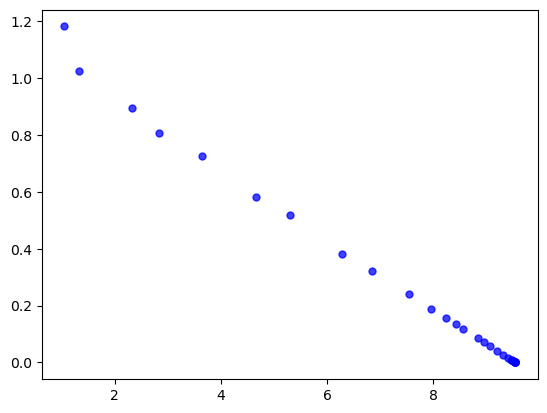

In [31]:
plt.errorbar(corrected_voltage, df["Voltage"]/df["Resistance"], fmt="o", ms=5, color="blue", alpha=0.75)

In [ ]:
voltage = df["Voltage"]
dvoltage = df["Voltage Uncertainty"]

resistance = df["Resistance"]
dresistance = df["Resistance Uncertainty"]

Reff = 1/ ( (1 / resistance) + ( 1 / 11.264160e6) )

# v = IR
# I = R 
current = voltage /  Reff # resistance

dcurrent = np.sqrt( (dvoltage * (1/resistance) ) ** 2 + (dresistance * ( - voltage) * (1 / (resistance ** 2))) ** 2)

y_var =  current
y_uncertainty = dcurrent

x_var = voltage
x_uncertainty = dvoltage

In [20]:
1 / resistance

3     1.002004e-05
1     1.004016e-06
2     5.015045e-07
4     1.002004e-04
8     1.642036e-04
7     1.964637e-04
6     5.020080e-04
10    7.535795e-04
5     1.002004e-03
12    1.824818e-03
9     3.048780e-03
11    4.566210e-03
19    6.631300e-03
14    8.291874e-03
13    9.950249e-03
21    1.414427e-02
20    1.647446e-02
15    1.968504e-02
17    2.457002e-02
18    3.278689e-02
16    4.878049e-02
28    6.451613e-02
22    9.900990e-02
29    1.298701e-01
23    2.000000e-01
24    2.941176e-01
25    3.846154e-01
26    7.692308e-01
27    1.000000e+00
Name: Resistance, dtype: float64

In [21]:
1 / 1.2360665024610162e3

0.0008090179598015105

In [22]:
np.sqrt( (dvoltage * (1/resistance) ) ** 2 + (dresistance * ( - voltage) * (1 / (resistance ** 2))) ** 2)

3     1.172462e-06
1     1.333416e-07
2     6.252142e-08
4     1.166925e-05
8     2.074114e-05
7     2.578916e-05
6     5.398618e-05
10    8.353085e-05
5     1.142570e-04
12    2.292290e-04
9     4.368910e-04
11    7.584079e-04
19    6.887712e-04
14    8.688808e-04
13    1.054598e-03
21    1.537073e-03
20    1.814999e-03
15    2.210041e-03
17    2.834633e-03
18    3.951049e-03
16    6.291836e-03
28    8.628553e-03
22    1.513194e-02
29    2.051936e-02
23    3.567352e-02
24    5.475647e-02
25    7.707155e-02
26    1.658393e-01
27    2.459832e-01
dtype: float64

In [23]:
# for x, y in zip(x_var, y_var):
#     print(x, ",", y)

In [33]:
#Preparing the Plots
x_label = "Voltage (Volts)"
y_label = "Current (Amperes)"
title = "Current (I) to Voltage (V) of Resistor Over 9V Battery"
xmax = max(x_var) * 1.05
xmin = 0 # min(x_var) - (xmax * 0.05)

ymin = min(y_var) * 0.95
ymax = max(y_var) * 1.05

Now lets make a graph of y_var vs. x_var, with error bars on the y data.

Text(0.5, 1.0, 'Current (I) to Voltage (V) of Resistor Over 9V Battery')

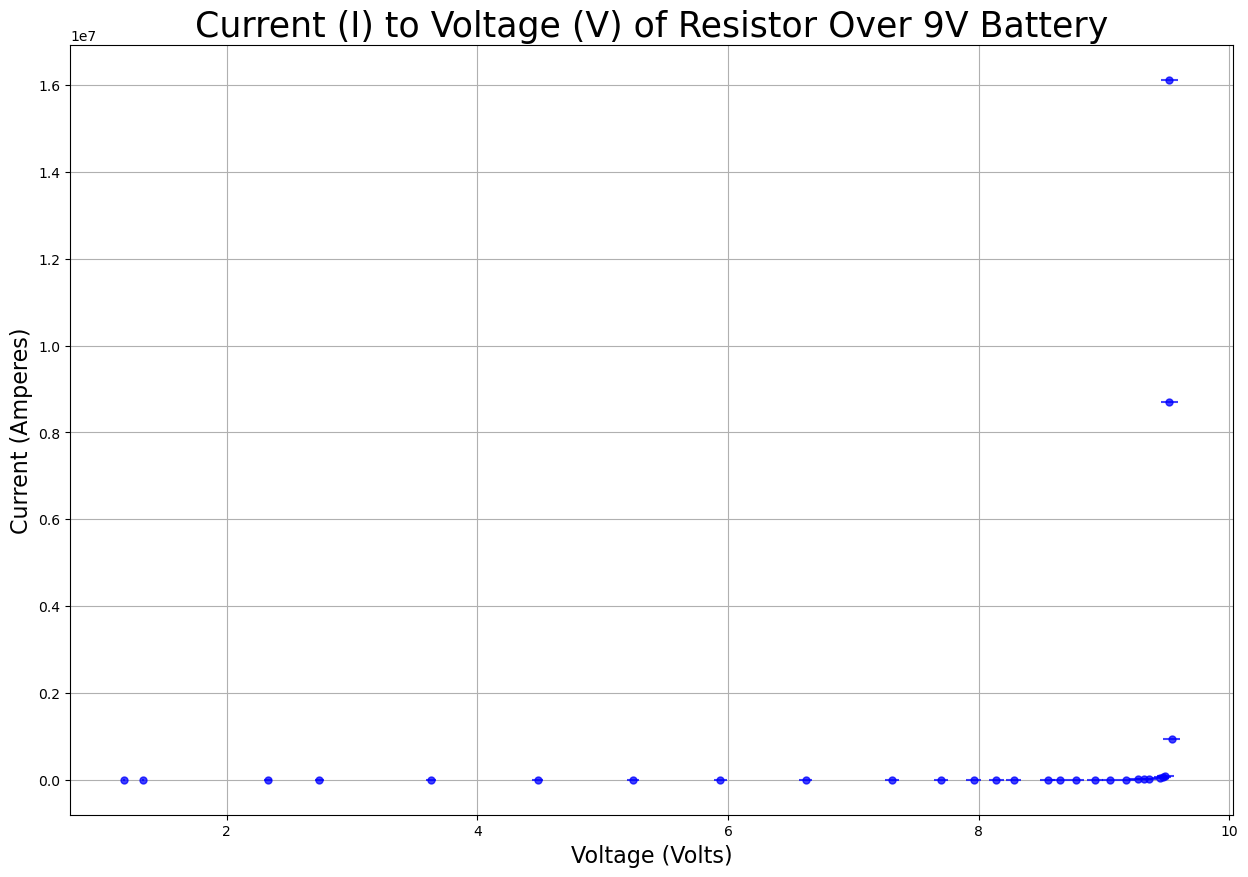

In [34]:
plt.errorbar(x_var, y_var, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="blue", alpha=0.75)

plt.gcf().set_size_inches(15, 10)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel(y_label, fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

# To manually change the axis limits, uncomment (remove the # at the start) these lines:
#plt.ylim(ymin, ymax)  # This sets the range of the y-axis
#plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# To save the plot as a .png, uncomment this:
#plt.savefig("plot", bbox_inches="tight", dpi=300)  # Saves the figure

In [ ]:
def FitFunction(x, m, b):
    y = m * x + b
    return y

n_parameters = 2

In [ ]:
#Parameter Bounds ([lower bounds,...],[Upper bounds,...])
param_bounds=([-np.inf,-np.inf],[np.inf,np.inf])  
initial_param=(1,1)  

In [ ]:
# cut = 15
# optimized_parameters, covariance_matrix = curve_fit(FitFunction, x_var[cut:],y_var[cut:],
#                                                     sigma=y_uncertainty[cut:],absolute_sigma=True,
#                                                     bounds=param_bounds,p0=initial_param)
# parameter_errors = np.sqrt(np.diag(covariance_matrix))

In [ ]:
from scipy.odr import * 

In [ ]:
mydata = RealData(x_var, y_var, sx=x_uncertainty, sy=y_uncertainty)

def f(B, x):
    '''Linear function y = m*x + b'''
    # B is a vector of the parameters.
    # x is an array of the current x values.
    # x is in the same format as the x passed to Data or RealData.
    #
    # Return an array in the same format as y passed to Data or RealData.
    return B[0]*x + B[1]

linear = Model(f)

myodr = ODR(mydata, linear, beta0=[1., 2.])

myoutput = myodr.run()

myoutput.pprint()

Beta: [-0.11440554  1.08064061]
Beta Std Error: [0.00224243 0.01947096]
Beta Covariance: [[ 2.50978394e-06 -2.16428946e-05]
 [-2.16428946e-05  1.89222304e-04]]
Residual Variance: 2.003560058211258
Inverse Condition #: 0.012227690547152868
Reason(s) for Halting:
  Sum of squares convergence


In [ ]:
optimized_parameters = myoutput.beta
parameter_errors = myoutput.sd_beta
# parameter_errors = np.sqrt(np.diag(myoutput.cov_beta))

## Plotting the fit results:

In [ ]:
for i in range(len(optimized_parameters)):
    print(f'Parameter #{i+1}: {optimized_parameters[i]:.6e} ± {parameter_errors[i]:.1e}')

Parameter #1: -1.144055e-01 ± 2.2e-03
Parameter #2: 1.080641e+00 ± 1.9e-02


In [ ]:
# First calculate a reasonable range of x values for our line
x_length = max(x_var) - min(x_var)
x_min_l = min(x_var) - 0.05*x_length
x_max_l = max(x_var) + 0.05*x_length
# Create our array of 200 linearly-spaced points
xForLine = np.linspace(x_min_l,x_max_l,200)
# Calculate the y values of the best fit line
yForLine = FitFunction(xForLine,*optimized_parameters)

In [ ]:
residual = y_var - FitFunction(x_var,*optimized_parameters)

In [ ]:
ndof = len(x_var) - len(optimized_parameters) - 1 # Number of degrees of freedom ndof = no. entries - no. parameters -1
ru = residual / y_uncertainty
chisq = np.sum(np.power(ru, 2)) / ndof
print("Chisq", str.format("{0:.4f}", chisq))  # Print 4 significant figures

Chisq 3162671450.9088


Now we are ready to plot the fit function with our data. We repeat the code to plot the previous graph, and then plot our fit function.

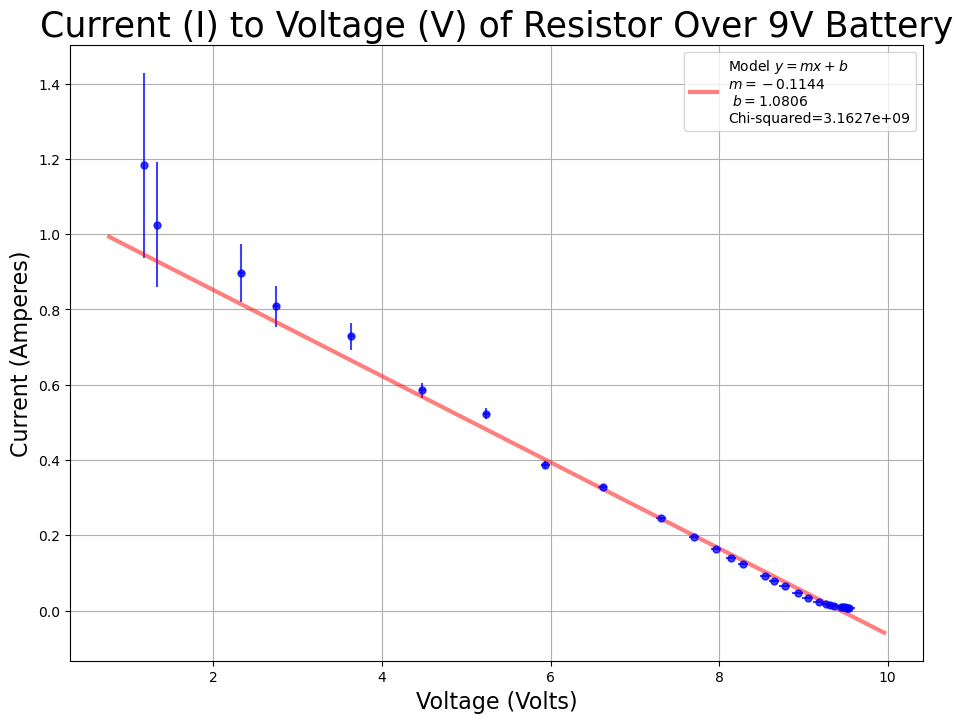

In [ ]:
# Plot our data
plt.errorbar(x_var, y_var, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="blue", alpha=0.75)

# Add grid lines, titles, and axis labels.
plt.gcf().set_size_inches(11, 8)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel(y_label, fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

# To manually change the axis limits, uncomment (remove the # at the start) these lines:
#plt.ylim(ymin, ymax)  # This sets the range of the y-axis
#plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# Add the line to the plot
plt.plot(xForLine, yForLine, lw=3, color="red", alpha=0.5, 
         label=f'Model $y = mx + b$ \n$m={optimized_parameters[0]:.4f}$ \n $b={optimized_parameters[1]:.4f}$\nChi-squared={chisq:.4e}')

# Add a legend
plt.legend()

# To save the plot as a .png, uncomment this:
# plt.savefig("plot_fit", bbox_inches="tight", dpi=300)  # Saves the figure
plt.savefig("figures/current_to_voltage.svg", bbox_inches="tight")  # Saves the figure

plt.show()

(0.0, 10.017)

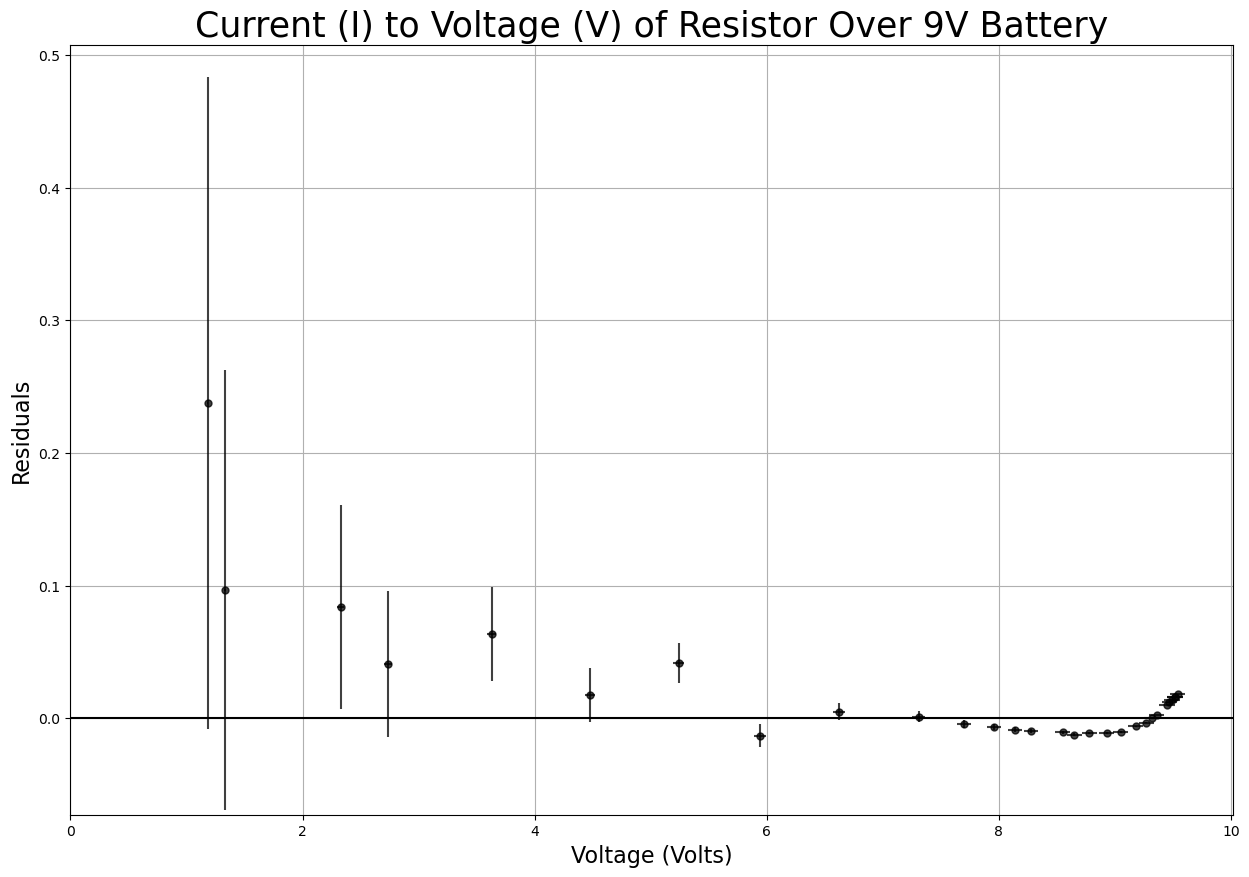

In [ ]:
# Plot the residuals
plt.errorbar(x_var, residual, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="black", alpha=0.75)

# Add grid lines, titles, and axis labels.
plt.gcf().set_size_inches(15, 10)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel("Residuals", fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

plt.axhline(0, color="black")


# Set the axis limits for the residuals plot
ymin_r= min(residual - y_uncertainty) * 1.05
ymax_r= max(residual + y_uncertainty) * 1.05
plt.ylim(ymin_r, ymax_r)  # This sets the range of the y-axis
plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# To save the plot as a .png, uncomment this:
#plt.savefig("plot_residuals", bbox_inches="tight", dpi=300)  # Saves the figure

Lets also calculate the $\chi^2$ value for our fit. This indicates the goodness-of-fit:
- $\chi^2>>1$ indicates the model is not a good fit to the data, or uncertainties are likely underestimated.
- $\chi^2\sim1$ indicates the model is a good fit to the data.
- $\chi^2<<1$ indicates the model is "too good" a fit, i.e. the uncertainties are likely overestimated.

In [ ]:
m = optimized_parameters[0]
dm = parameter_errors[0]
print(f"Internal Resistance = {-1/m:.4f} ± {(dm)* (1/(m**2) ) :.4f}")

Internal Resistance = 8.7408 ± 0.1713


In [ ]:
# ndof = len(x_var[cut:]) - len(optimized_parameters) - 1 # Number of degrees of freedom ndof = no. entries - no. parameters -1
# ru = residual[cut:] / y_uncertainty[cut:]
# chisq = np.sum(np.power(ru, 2)) / ndof
# print("Corrected Chisq", str.format("{0:.4f}", chisq))  # Print 4 significant figures

# This time cutting the data

In [ ]:
cut = 13

cut_x_var = x_var[:cut]
cut_y_var = y_var[:cut]
cut_x_uncertainty = x_uncertainty[:cut]
cut_y_uncertainty= y_uncertainty[:cut]

x_var = x_var[cut:]
y_var = y_var[cut:]
x_uncertainty = x_uncertainty[cut:]
y_uncertainty= y_uncertainty[cut:]



In [ ]:
mydata = RealData(x_var, y_var, sx=x_uncertainty, sy=y_uncertainty)

def f(B, x):
    '''Linear function y = m*x + b'''
    # B is a vector of the parameters.
    # x is an array of the current x values.
    # x is in the same format as the x passed to Data or RealData.
    #
    # Return an array in the same format as y passed to Data or RealData.
    return B[0]*x + B[1]

linear = Model(f)

myodr = ODR(mydata, linear, beta0=[1., 2.])

myoutput = myodr.run()

myoutput.pprint()

Beta: [-0.12311223  1.14298083]
Beta Std Error: [0.00209968 0.01621541]
Beta Covariance: [[ 6.53592861e-06 -5.00245039e-05]
 [-5.00245039e-05  3.89813611e-04]]
Residual Variance: 0.6745259127882163
Inverse Condition #: 0.015540274623809082
Reason(s) for Halting:
  Sum of squares convergence


In [ ]:
optimized_parameters = myoutput.beta
parameter_errors = myoutput.sd_beta

## Plotting the fit results:

In [ ]:
for i in range(len(optimized_parameters)):
    print(f'Parameter #{i+1}: {optimized_parameters[i]:.6e} ± {parameter_errors[i]:.1e}')

Parameter #1: -1.231122e-01 ± 2.1e-03
Parameter #2: 1.142981e+00 ± 1.6e-02


In [ ]:
m = optimized_parameters[0]
dm = parameter_errors[0]
print(f"Internal Resistance = {-1/m:.4f} ± {(dm)* (1/(m**2) ) :.4f}")

Internal Resistance = 8.1227 ± 0.1385


In [ ]:
# First calculate a reasonable range of x values for our line
x_length = max(x_var) - min(x_var)
x_min_l = min(x_var) - 0.05*x_length
x_max_l = max(x_var) + 0.05*x_length
# Create our array of 200 linearly-spaced points
xForLine = np.linspace(x_min_l,x_max_l,200)
# Calculate the y values of the best fit line
yForLine = FitFunction(xForLine,*optimized_parameters)

Now we are ready to plot the fit function with our data. We repeat the code to plot the previous graph, and then plot our fit function.

In [ ]:
residual = y_var - FitFunction(x_var,*optimized_parameters)
cut_residual = cut_y_var - FitFunction(cut_x_var,*optimized_parameters)

Lets also calculate the $\chi^2$ value for our fit. This indicates the goodness-of-fit:
- $\chi^2>>1$ indicates the model is not a good fit to the data, or uncertainties are likely underestimated.
- $\chi^2\sim1$ indicates the model is a good fit to the data.
- $\chi^2<<1$ indicates the model is "too good" a fit, i.e. the uncertainties are likely overestimated.

In [ ]:
ndof = len(x_var) - len(optimized_parameters) - 1 # Number of degrees of freedom ndof = no. entries - no. parameters -1
ru = residual / y_uncertainty
chisq = np.sum(np.power(ru, 2)) / ndof
print("Chisq", str.format("{0:.4f}", chisq))  # Print 4 significant figures

Chisq 1.1983


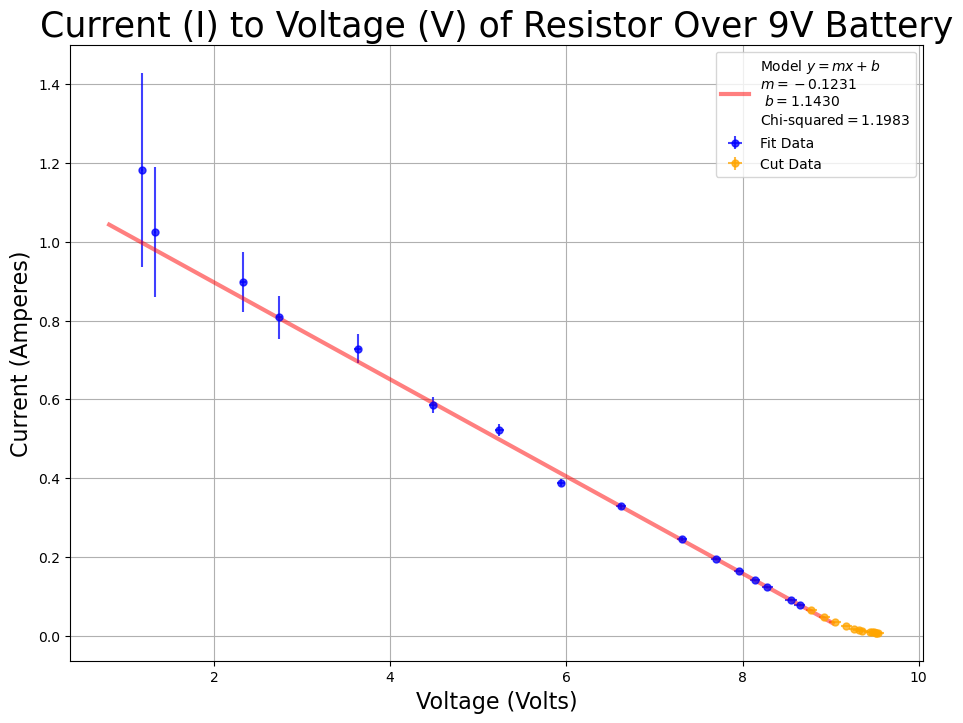

In [ ]:
# Plot our data
plt.errorbar(x_var, y_var, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="blue", alpha=0.75, label="Fit Data")

plt.errorbar(cut_x_var, cut_y_var, yerr=cut_y_uncertainty, xerr=cut_x_uncertainty, fmt="o", ms=5, color="orange", alpha=0.75, label="Cut Data")


# Add grid lines, titles, and axis labels.
plt.gcf().set_size_inches(11, 8)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel(y_label, fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

# To manually change the axis limits, uncomment (remove the # at the start) these lines:
#plt.ylim(ymin, ymax)  # This sets the range of the y-axis
#plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# Add the line to the plot
plt.plot(xForLine, yForLine, lw=3, color="red", alpha=0.5, 
         label=f'Model $y = mx + b$ \n$m={optimized_parameters[0]:.4f}$ \n $b={optimized_parameters[1]:.4f}$\nChi-squared$={chisq:.4f}$')

# Add a legend
plt.legend()

# To save the plot as a .png, uncomment this:
# plt.savefig("plot_fit", bbox_inches="tight", dpi=300)  # Saves the figure
plt.savefig("figures/current_to_voltage_cut.svg", bbox_inches="tight")  # Saves the figure

plt.show()

(0.0, 10.017)

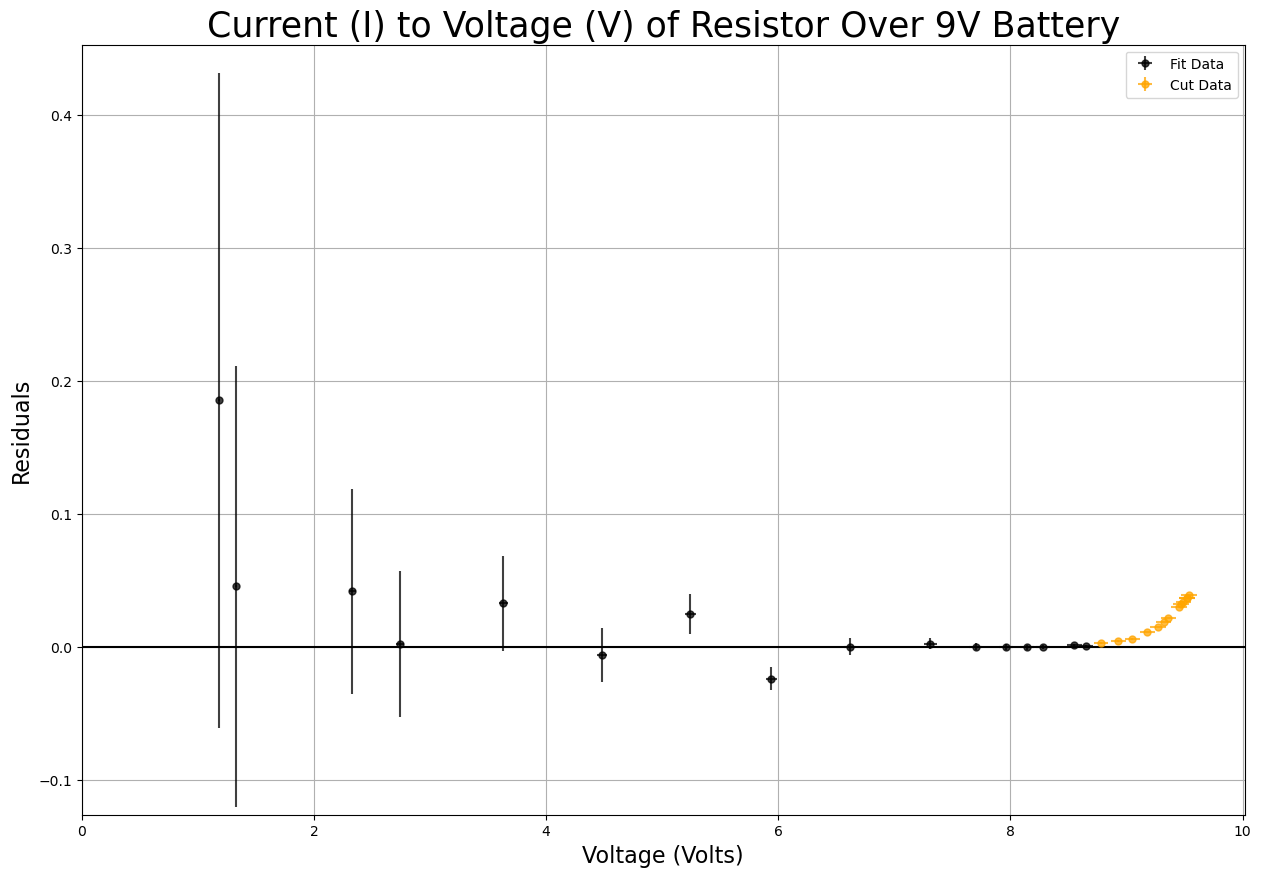

In [ ]:
# Plot the residuals
plt.errorbar(x_var, residual, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="black", alpha=0.75, label="Fit Data")

plt.errorbar(cut_x_var, cut_residual, yerr=cut_y_uncertainty, xerr=cut_x_uncertainty, fmt="o", ms=5, color="orange", alpha=0.75, label="Cut Data")

# Add grid lines, titles, and axis labels.
plt.gcf().set_size_inches(15, 10)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel("Residuals", fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

plt.axhline(0, color="black")

# Add a legend
plt.legend()

# Set the axis limits for the residuals plot
ymin_r= min(residual - y_uncertainty) * 1.05
ymax_r= max(residual + y_uncertainty) * 1.05
plt.ylim(ymin_r, ymax_r)  # This sets the range of the y-axis
plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# To save the plot as a .png, uncomment this:
#plt.savefig("plot_residuals", bbox_inches="tight", dpi=300)  # Saves the figure